In [1]:
import torch 
import torch.nn as nn

layer=nn.Linear(3,2)
x=torch.tensor([[1.0,2.0,3.0]])

y=layer(x)

print(y)

tensor([[0.3333, 1.1688]], grad_fn=<AddmmBackward0>)


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.Linear=nn.Linear(1,1)
    def forward(self,x):
        return self.Linear(x)

x=torch.tensor([[1.],[2.],[3.],[4.]])

y=torch.tensor([[2.],[4.],[6.],[8.]])

model = MyModel()

loss_fn=nn.MSELoss()
optimiser=optim.Adam(model.parameters(), lr=0.1)

for epoch in range (10):
    optimiser.zero_grad()
    y_pred=model(x)
    loss = loss_fn(y_pred,y)
    loss.backward()
    optimiser.step()

    print(f"Epoch {epoch +1}, Loss:{loss.item():.4f}")
    
torch.save(model.state_dict()," linear_model.pth")

Epoch 1, Loss:47.5990
Epoch 2, Loss:42.7252
Epoch 3, Loss:38.1296
Epoch 4, Loss:33.8164
Epoch 5, Loss:29.7890
Epoch 6, Loss:26.0495
Epoch 7, Loss:22.5990
Epoch 8, Loss:19.4369
Epoch 9, Loss:16.5614
Epoch 10, Loss:13.9688


using device cpu


100%|██████████| 9.91M/9.91M [00:17<00:00, 563kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 114kB/s]
100%|██████████| 1.65M/1.65M [00:03<00:00, 436kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.13MB/s]


6/5| Loss:318.4723
6/5| Loss:132.1148
6/5| Loss:91.8726
6/5| Loss:67.8206
6/5| Loss:53.2449
Total Accuracy:97.54%
model saved as mnist_model.pth


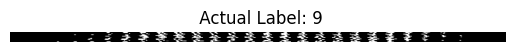

user picked image index 1000
Actual Label 9
Model Prediction 9


In [3]:
import torch 
import torch.nn as nn
import torch.optim as optim

from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

device ="cuda" if torch.cuda.is_available() else "cpu"
print("using device",device)

transform =transforms.ToTensor()

train_data =MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_data =MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)
train_loader=DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

test_loader =DataLoader(
    test_data,
    batch_size=64,
    shuffle=False
)

class digimodel(nn.Module):
    def __init__(self):
        super().__init__()

        self.net=nn.Sequential(
            nn.Linear(28*28,128),
            nn.ReLU(),

            nn.Linear(128,64),
            nn.ReLU(),

            nn.Linear(64,10)
            
        )

    def forward(self,x):
        return self.net(x)

model=digimodel().to(device)

loss_fn= nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)

epoch =5
for i in range (epoch):
    model.train()
    total_loss=0
    for images, labels in train_loader:
        images = images.view(images.size(0),-1).to(device)
        labels=labels.to(device)

        optimizer.zero_grad()
        output = model(images)
        loss=loss_fn(output,labels)
        loss.backward()
        optimizer.step()

        total_loss+=loss.item()

    print(f"{epoch+1}/{epoch}| Loss:{total_loss:.4f}")

model.eval()
correct=0
total=0
with torch.no_grad():
    for images, labels in test_loader:
        images=images.view(images.size(0),-1).to (device)
        labels=labels.to(device)

        output=model(images)
        prediction =output.argmax(dim=1)

        correct+=(prediction == labels).sum().item()
        total+=labels.size(0)

accuracy =100*correct/total
print(f"Total Accuracy:{accuracy:.2f}%")

torch.save(model.state_dict(),"mnist_model.pth")
print("model saved as mnist_model.pth")

index=1000
image, true_label =test_data[index]

plt.imshow(images.squeeze(),cmap="gray")
plt.title(f" Actual Label: {true_label}")
plt.axis("off")
plt.show()

image_flat= image.view(1,-1).to(device)

with torch.no_grad():
    output=model(image_flat)
    predicted_label =output.argmax(dim=1).item()

print("user picked image index", index)
print("Actual Label",true_label)
print("Model Prediction",predicted_label)

                             

In [4]:
import torch
import torch.nn as nn

image=torch.randn(1,1,28,28)

conv=nn.Conv2d(
    in_channels=1,
    out_channels=8,
    kernel_size=3,
    stride=1,
    padding=1
)
output=conv(image)

print("input image",image.shape)
print("output image",output.shape)



input image torch.Size([1, 1, 28, 28])
output image torch.Size([1, 8, 28, 28])
